In [1]:
import numpy as np
from time import time
import matplotlib.pyplot as plt
import matplotlib

# latex style
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Palatino"],
    }
)

In [2]:
def d1_function(k, fc):
    kx, ky, kz = k
    d = fc[1] * np.exp(1j * kx) + fc[2] * np.exp(1j * ky) + fc[3] * np.exp(1j * kz)
    return fc[0].real + (d + np.conj(d)).real / 2


def make_right_fc(rng=None, nonzero_imag_index=None):
    if rng is None:
        rng = np.random.default_rng()
    fc = rng.uniform(-1, 1, 4) + 1j * rng.uniform(-1, 1, 4)

    fc[0] = fc[0].real  # make first term real

    # make sure real terms cancel
    fc[3] = -fc[0] + 1j * fc[3].imag
    fc[2] = fc[1].real + 1j * fc[2].imag

    # make imaginary terms positive
    fc = fc.real - 1j * np.abs(fc.imag)

    if nonzero_imag_index is not None:
        nonzero_imag = fc[nonzero_imag_index].imag
        fc = fc.real + 0 * 1j
        fc[nonzero_imag_index] += 1j * np.abs(nonzero_imag)

    return fc


def d_function(k, fc_set):
    d1 = d1_function(k, fc_set[0])
    d2 = d1_function(k, fc_set[1])
    d3 = d1_function(k, fc_set[2])
    return np.array([d1, d2, d3])


k_vals = np.linspace(-np.pi, np.pi, 100, endpoint=False)
KX, KY = np.meshgrid(k_vals, k_vals)

# choose the function coefficients
# seed = int(time() * 1000)
# rng = np.random.default_rng(seed)
fc_set = [make_right_fc(rng, i + 1) for i in range(3)]
fc_set[0] = np.conjugate(fc_set[0])
# print(fc_set[0])
print("Function coefficients:")

# fc_set[2]*= 2
# fc_set[2][3] = fc_set[2][3].real  # make one imaginary term nonzero

for i, fc in enumerate(fc_set):
    print(f"fc[{i}] = {fc}")

NameError: name 'rng' is not defined

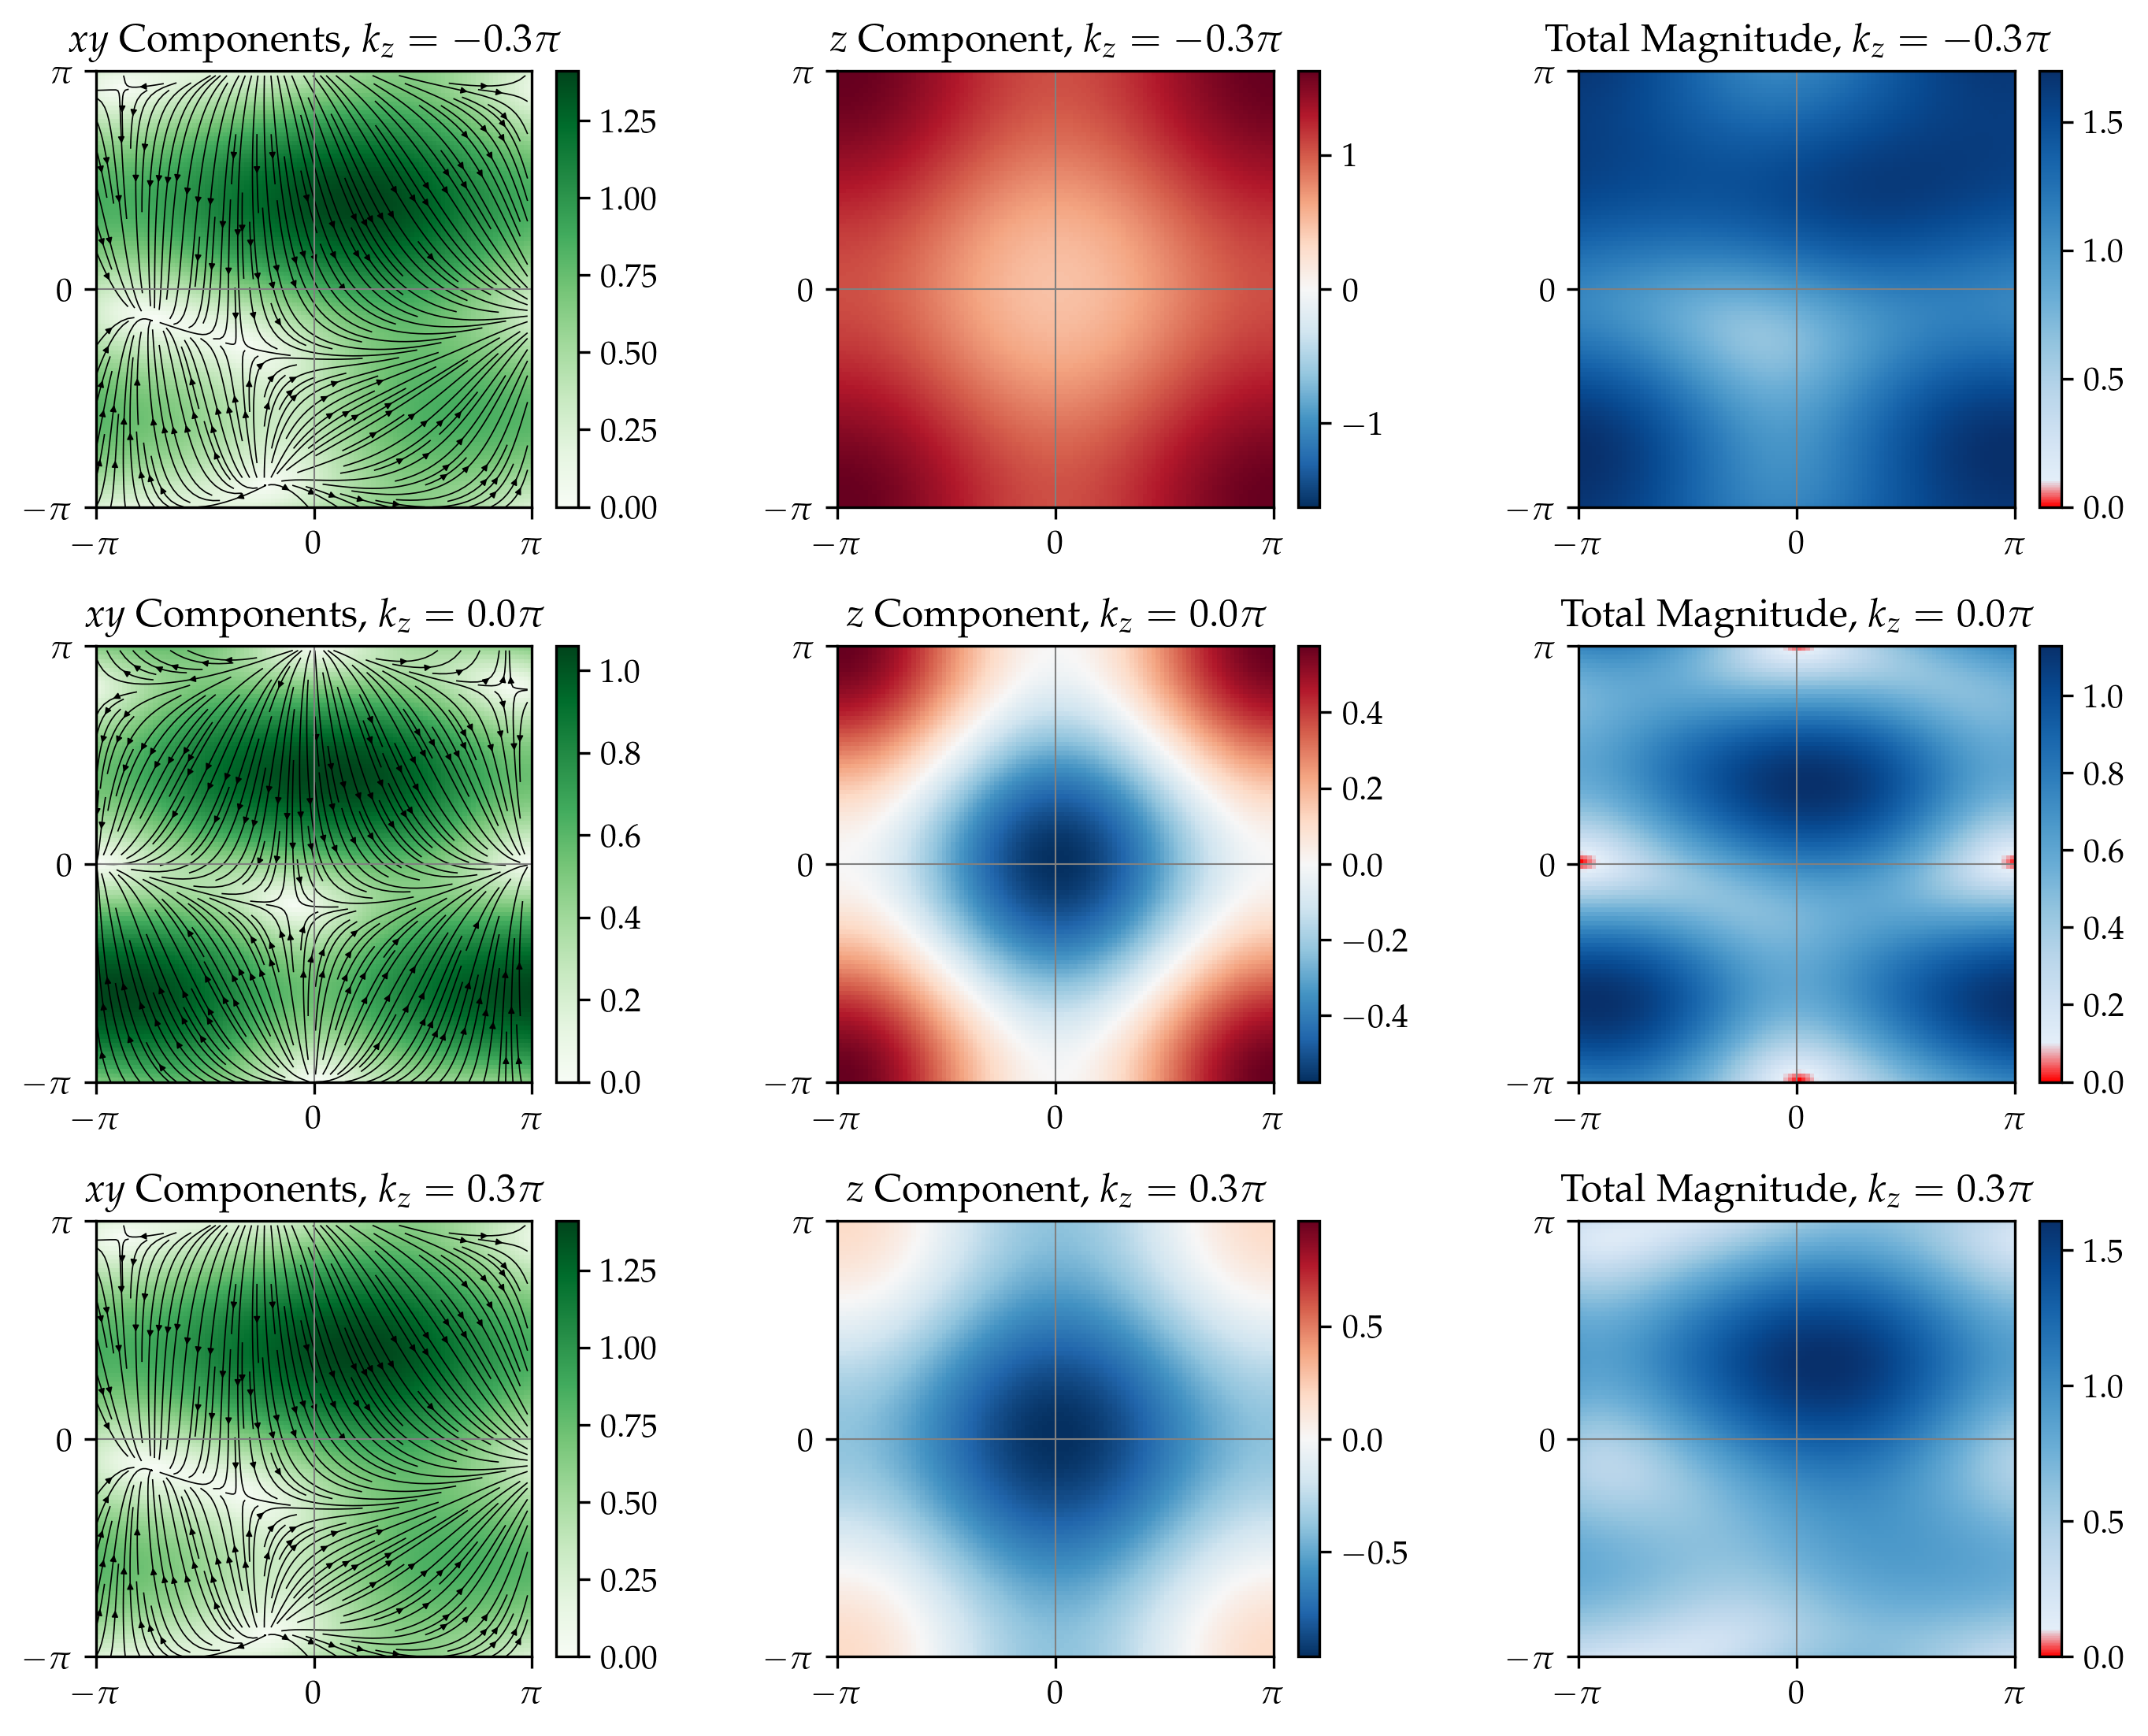

In [ ]:
kz_values = np.linspace(-0.3, 0.3, 3, endpoint=True)

# document_width in mm
document_width = 240
figwidth = document_width / 25.4
figheight = len(kz_values) * figwidth / 3 - 2

fig, axes = plt.subplots(
    len(kz_values), 3, figsize=(document_width / 25.4, figheight), dpi=300
)

for j, kz in enumerate(kz_values):

    d_values = np.array(
        [
            d_function((kx, ky, kz * np.pi), fc_set)
            for kx, ky in zip(np.ravel(KX), np.ravel(KY))
        ]
    )
    DX = d_values[:, 0].reshape(KX.shape)
    DY = d_values[:, 1].reshape(KX.shape)
    DZ = d_values[:, 2].reshape(KX.shape)
    mag = np.sqrt(DX**2 + DY**2 + DZ**2)
    mags_xy = np.sqrt(DX**2 + DY**2)

    ax = axes[j]

    im = ax[0].streamplot(
        KX, KY, DX, DY, color="black", linewidth=0.4, density=2, arrowsize=0.4
    )
    im_mag = ax[0].imshow(
        mags_xy,
        extent=(-np.pi, np.pi, -np.pi, np.pi),
        origin="lower",
        cmap="Greens",
        vmin=0,
        vmax=np.max(mags_xy),
    )

    mag_z = ax[1].imshow(
        DZ,
        extent=(-np.pi, np.pi, -np.pi, np.pi),
        origin="lower",
        cmap="RdBu_r",
        vmin=-np.max(np.abs(DZ)),
        vmax=np.max(np.abs(DZ)),
    )

    cvals = [0.0, *np.linspace(0.1, np.max(mag), 10)]
    green = matplotlib.colormaps["Blues"]
    colors = [
        "red",
        *[green(i) for i in np.linspace(0.1, 1, 10)],
    ]

    norm = plt.Normalize(min(cvals), max(cvals))
    tuples = list(zip(map(norm, cvals), colors))
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

    mag_sum = ax[2].imshow(
        mag,
        extent=(-np.pi, np.pi, -np.pi, np.pi),
        origin="lower",
        cmap=cmap,
        norm=norm,
    )

    # choose colourmap for cbar
    cbar1 = fig.colorbar(im_mag, ax=ax[0], fraction=0.046, pad=0.04)
    cbar2 = fig.colorbar(mag_z, ax=ax[1], fraction=0.046, pad=0.04)
    cbar3 = fig.colorbar(mag_sum, ax=ax[2], fraction=0.046, pad=0.04)

    ax[0].set_title(r"$xy$ Components, $k_z={:.1f}\pi$".format(kz))
    ax[1].set_title(r"$z$ Component, $k_z={:.1f}\pi$".format(kz))
    ax[2].set_title(r"Total Magnitude, $k_z={:.1f}\pi$".format(kz))

for ax in axes.flatten():
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_yticks([-np.pi, 0, np.pi])
    ax.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])

    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)

plt.tight_layout()
plt.savefig("d_vector_plots.png", dpi=300)